In [1]:
import pandas as pd

try:
    df = pd.read_excel("dataset .csv.xlsx")
    print("Loaded 'dataset .csv.xlsx' successfully!")
    display(df.head())
except Exception as e:
    print("Could not read this file:", e)

Loaded 'dataset .csv.xlsx' successfully!


,refArea,EndDate,Currency,Item Code,StartDate,Value,Observation URI,references,Month,publisher,Year,Item,dataset
0,http://dbpedia.org/resource/Lebanon,1970-12-31,Lebanese Pound,LCU,1970-01-01,3.268983,http://linked.aub.edu.lb/CODEC/Lebanon/observa...,https://data.humdata.org/dataset/faostat-food-...,Annual value,Food and Agriculture Organization,1970,Local currency units per USD,http://linked.aub.edu.lb/CODEC/Lebanon/Dataset...
1,http://dbpedia.org/resource/Lebanon,1971-12-31,Lebanese Pound,LCU,1971-01-01,3.227733,http://linked.aub.edu.lb/CODEC/Lebanon/observa...,https://data.humdata.org/dataset/faostat-food-...,Annual value,Food and Agriculture Organization,1971,Local currency units per USD,http://linked.aub.edu.lb/CODEC/Lebanon/Dataset...
2,http://dbpedia.org/resource/Lebanon,1972-12-31,Lebanese Pound,LCU,1972-01-01,3.050717,http://linked.aub.edu.lb/CODEC/Lebanon/observa...,https://data.humdata.org/dataset/faostat-food-...,Annual value,Food and Agriculture Organization,1972,Local currency units per USD,http://linked.aub.edu.lb/CODEC/Lebanon/Dataset...
3,http://dbpedia.org/resource/Lebanon,1973-12-31,Lebanese Pound,LCU,1973-01-01,2.610400,http://linked.aub.edu.lb/CODEC/Lebanon/observa...,https://data.humdata.org/dataset/faostat-food-...,Annual value,Food and Agriculture Organization,1973,Local currency units per USD,http://linked.aub.edu.lb/CODEC/Lebanon/Dataset...
4,http://dbpedia.org/resource/Lebanon,1974-12-31,Lebanese Pound,LCU,1974-01-01,2.327758,http://linked.aub.edu.lb/CODEC/Lebanon/observa...,https://data.humdata.org/dataset/faostat-food-...,Annual value,Food and Agriculture Organization,1974,Local currency units per USD,http://linked.aub.edu.lb/CODEC/Lebanon/Dataset...


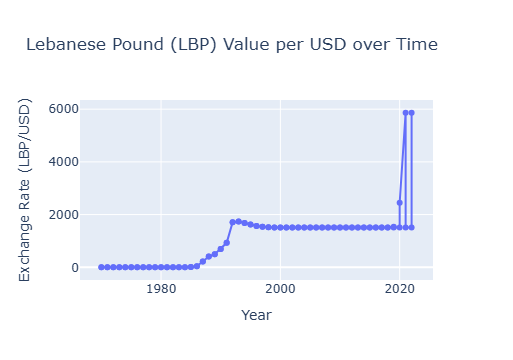

In [2]:
import plotly.express as px

# Filter data to look purely at Annual trend points to avoid overlapping monthly duplicates
df_annual = df[df["Month"] == "Annual value"].sort_values("Year")

fig1 = px.line(
    df_annual,
    x="Year",
    y="Value",
    title="Lebanese Pound (LBP) Value per USD over Time",
    markers=True,
    labels={"Value": "Exchange Rate (LBP/USD)"},
)
fig1.show()


In [ ]:
fig1.write_html("graph1.html")

import plotly.express as px

# 1. Create your chart
df_annual = df[df["Month"] == "Annual value"].sort_values("Year")
fig1 = px.line(df_annual, x="Year", y="Value", title="LBP per USD over Time")

# 2. Display it in the notebook
fig1.show()

# 3. SAVE IT AUTOMATICALLY TO YOUR COMPUTER
# This will save 'line_chart.png' directly into your C:\Users\USP folder!
fig1.write_image("line_chart.png", width=1200, height=600, scale=2)
print("Chart successfully saved as line_chart.png!")
fig1.write_html("graph1.html")

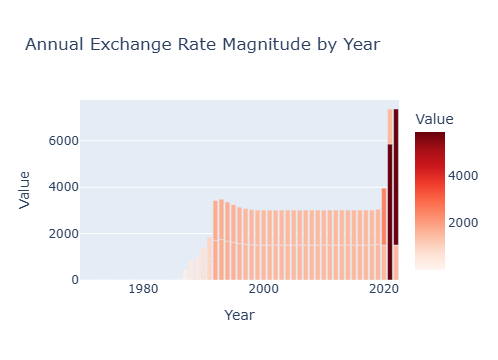

In [7]:
fig2 = px.bar(
    df_annual,
    x="Year",
    y="Value",
    color="Value",
    title="Annual Exchange Rate Magnitude by Year",
    color_continuous_scale="Reds",
)
fig2.show()

fig2.write_html("graph2.html")

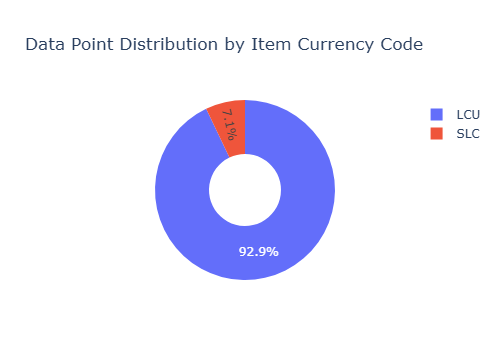

In [8]:
fig3 = px.pie(
    df,
    names="Item Code",
    title="Data Point Distribution by Item Currency Code",
    hole=0.4,  # Turns it into a clean donut chart
)
fig3.show()
fig3.write_html("graph3.html")

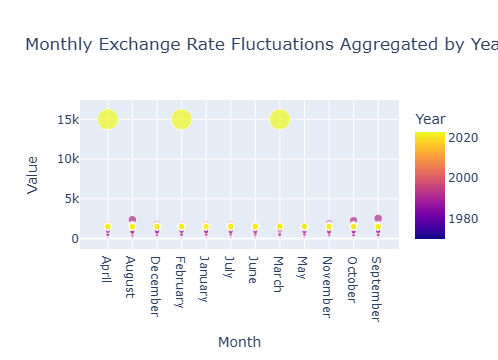

In [9]:
# Filter out the 'Annual value' rows to focus strictly on calendar months
df_months = df[df["Month"] != "Annual value"]

fig4 = px.scatter(
    df_months,
    x="Month",
    y="Value",
    color="Year",
    title="Monthly Exchange Rate Fluctuations Aggregated by Year",
    size="Value",
    size_max=15,
)
fig4.show()
fig4.write_html("graph4.html")


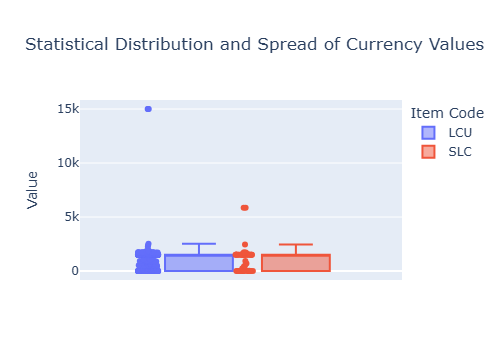

In [10]:
fig5 = px.box(
    df,
    y="Value",
    color="Item Code",
    title="Statistical Distribution and Spread of Currency Values",
    points="all",  # Show individual underlying records alongside the summary box
)
fig5.show()
fig5.write_html("graph5.html")